<a href="https://colab.research.google.com/github/AbdennourKerPro/MVA_26-27/blob/main/tp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Context**: In this TP, we will use MedMNIST, a large-scale MNIST-like collection of standardized biomedical images, including 12 datasets for 2D and 6 datasets for 3D. All images are pre-processed into different sizes: 28x28, 64x64, 128x128 and 256x256 with the corresponding classification labels. The size of the datasets varies from 100 to 100,000 images with different tasks, in particular: binary/multi-class.

**Goal**: Implement and use at **two**  explainability methods seen during the lecture of today (e.g., Attribution, CAM, LIME) on at least **two** different networks and **two** MedMNIST datasets (e.g., PathMNISt and DermaMNIST). You can use the image size you want (the bigger, the easier to interpret but the more computational capability you will need, please choose according to your computational capability).

**Implementation**: for complex methods ([SHAP](https://shap.readthedocs.io/en/latest/), [LRP](https://github.com/sebastian-lapuschkin/lrp_toolbox), [Integrated Gradients](https://captum.ai/docs/introduction), DeepLIFT) you can use existign implementations. See also: https://github.com/interpretml/interpret, https://github.com/marcoancona/DeepExplain,

**Deadline**: Please check on the course website.

In [1]:
import os
import numpy as np
import torch

# In this notebook, we use data loaders with heavier computational processing. It is recommended to use as many
# workers as possible in a data loader, which corresponds to the number of CPU cores
NUM_WORKERS = os.cpu_count()
print("Number of workers:", NUM_WORKERS)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.determinstic = True
torch.backends.cudnn.benchmark = False

# For reproducibility
np.random.seed(666)
torch.manual_seed(666)

try:
  import google.colab
  IN_COLAB = True
  !pip install medmnist
except:
  IN_COLAB = False

Number of workers: 128


In [2]:
import os
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet18, resnet50
from tqdm import trange

import medmnist
from medmnist import INFO, Evaluator

import matplotlib.pyplot as plt
from PIL import Image
from skimage.segmentation import quickshift

print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")

MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/


In [3]:
print("Using torch", torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print ("MPS device found.")
elif torch.cuda.is_available():
    device = torch.device("cuda:0") # we use one GPU, the first one
    print ("CUDA device found.")
else:
   device = torch.device("cpu")
   print('No MPS or CUDA has been found. PyTorch will use CPU.')

Using torch 2.12.0.dev20260228+cu128
CUDA device found.


Here you can choose which dataset you want to use and the image size. Please use 28x28 at the beginning. Change the batch size according to your computational capability (1024 is good for Google Colab)

In [4]:
# Dataset Hyper-parameters
dataset_name = "pathmnist"  # Change this to any MedMNIST dataset (e.g., "chestmnist", "bloodmnist")
SIZE_IMAGES=28 # 28, 64, 128, 256
BATCH_SIZE = 1024

Here we download the data and create the datasets and loaders.

In [5]:
# Function to load any MedMNIST dataset
def load_medmnist(dataset_name, BATCH_SIZE, SIZE_IMAGES):
    info = INFO[dataset_name]
    num_classes = len(info["label"])
    in_channels = 3 if info["n_channels"] == 3 else 1  # Handle grayscale & RGB

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5] * in_channels, std=[0.5] * in_channels)
    ])

    DataClass = getattr(medmnist, info["python_class"])

    train_dataset = DataClass(split="train", transform=transform, download=True, size=SIZE_IMAGES)
    val_dataset = DataClass(split="val", transform=transform, download=True, size=SIZE_IMAGES)
    test_dataset = DataClass(split="test", transform=transform, download=True, size=SIZE_IMAGES)

    train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    task=info['task']

    return train_dataset, val_dataset, test_dataset,  train_loader, val_loader, test_loader, in_channels, num_classes, task

Here you can check the task, the number of data and verify the image size.

In [6]:
# Run training on any MedMNIST dataset
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader, in_channels, num_classes, task = load_medmnist(dataset_name, BATCH_SIZE, SIZE_IMAGES)

print('The task is', task)
# Get image size from the dataset
image_size = train_loader.dataset.imgs.shape[1]  # Works for all MedMNIST datasets
print('The size of images is ', image_size)

The task is multi-class
The size of images is  28


In [7]:
print(train_dataset)
print("===================")
print(val_dataset)
print("===================")
print(test_dataset)

Dataset PathMNIST of size 28 (pathmnist)
    Number of datapoints: 89996
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
    Number of samples: {'train': 89996, 'val': 10004, 'test': 7180}
    Description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K

The authors of MedMNIST has created a function to plot the images.

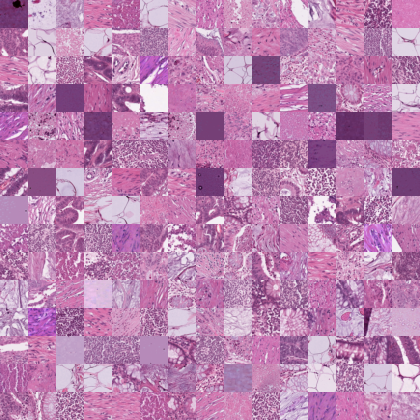

In [8]:
# montage
train_dataset.montage(length=15)

Please change the Number of epochs to 1 or 2 to test the code.

In [9]:
# Optimization Hyper-parameters
NUM_EPOCHS = 50
lr = 0.001

At first, we will use a very simple network proposed by the authors of MedMNIST. Look at it carefully. You will change it later on.

In [10]:
# define a simple CNN model (from MedMNIST website)
class Net(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Net, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU())

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


We can initalize the model and train it.

In [11]:
# Initialize model
model = Net(in_channels=in_channels, num_classes=num_classes)

**Question**: Look at the training and validation code. Why do we separate for binary and multi class ?

**Answer Q1 — Why do we separate binary and multi-class?**

The two tasks require different loss functions and different label formats:

| Aspect | Multi-label, binary-class | Multi-class |
|---|---|---|
| **Loss** | `BCEWithLogitsLoss` — each output neuron is an independent binary sigmoid; the loss is the sum of per-label binary cross-entropies. | `CrossEntropyLoss` — applies a softmax over all classes and computes a single negative log-likelihood. |
| **Labels** | Float tensor of shape `(B, C)` with 0/1 entries (one label per class, possibly several classes active). | Long integer tensor of shape `(B,)` containing the class index. |
| **Prediction** | Sigmoid → threshold at 0.5 per neuron. | Argmax over the logit vector. |

Using the wrong combination (e.g., `CrossEntropyLoss` on multi-label data) would produce incorrect gradients and meaningless predictions because the softmax would force the probabilities to sum to 1, which is not desired when multiple labels can be active simultaneously.

In [12]:
# Training Function
def train_model(model, train_loader, val_loader, task, num_epochs, lr):
    model.to(device)

    # Choose loss function based on the task type
    if task == "multi-label, binary-class":
        criterion = nn.BCEWithLogitsLoss().to(device)
    else: # multi-class
        criterion = nn.CrossEntropyLoss().to(device)

    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            if task == "multi-label, binary-class":
              labels = labels.to(torch.float32)  # Ensure float for BCEWithLogitsLoss
            else: # multi-class
              labels = labels.squeeze().long() # Convert one-hot to class index

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Compute Accuracy for CrossEntropyLoss or BCEWithLogitsLoss
            if task == "multi-label, binary-class":  # Binary classification
                outputs = torch.sigmoid(outputs)  # Apply sigmoid for binary classification
                predicted = (outputs >= 0.5).long()  # Threshold at 0.5 for binary classification
            else:  # Multi-class classification
                _, predicted = torch.max(outputs, 1)  # Get predicted class index

            correct += (predicted == labels).sum().item()
            total += labels.size(0)


        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {accuracy:.2f}%")


        # Validation phase
        model.eval()  # Set model to evaluation mode (disables dropout, batchnorm, etc.)
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # No need to compute gradients for validation
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                if task == "multi-label, binary-class":
                  labels = labels.to(torch.float32)  # Ensure float for BCEWithLogitsLoss
                else:
                  labels = labels.squeeze().long() # Convert one-hot to class index

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                # Compute Accuracy for CrossEntropyLoss or BCEWithLogitsLoss
                if task == "multi-label, binary-class":  # Binary classification
                    outputs = torch.sigmoid(outputs)  # Apply sigmoid for binary classification
                    predicted = (outputs >= 0.5).long()  # Threshold at 0.5 for binary classification
                else:  # Multi-class classification
                    _, predicted = torch.max(outputs, 1)

                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        # Compute validation accuracy
        val_accuracy = 100 * val_correct / val_total
        print(f"Epoch {epoch+1}/{num_epochs}, Val Loss: {val_loss/len(test_loader):.4f}, Val Accuracy: {val_accuracy:.2f}%")

    return model


You can now train your model.

In [13]:
trained_model = train_model(model, train_loader, val_loader, task, NUM_EPOCHS, lr)

100%|██████████| 88/88 [00:13<00:00,  6.43it/s]


Epoch 1/50, Loss: 2.0791, Accuracy: 27.27%
Epoch 1/50, Val Loss: 2.2882, Val Accuracy: 41.56%


100%|██████████| 88/88 [00:12<00:00,  6.95it/s]


Epoch 2/50, Loss: 1.4886, Accuracy: 47.43%
Epoch 2/50, Val Loss: 1.5746, Val Accuracy: 53.14%


100%|██████████| 88/88 [00:11<00:00,  7.66it/s]


...

Epoch 48/50, Loss: 0.1506, Accuracy: 94.92%
Epoch 48/50, Val Loss: 0.3488, Val Accuracy: 90.30%


100%|██████████| 88/88 [00:11<00:00,  7.73it/s]


Epoch 49/50, Loss: 0.1452, Accuracy: 95.12%
Epoch 49/50, Val Loss: 0.2917, Val Accuracy: 92.18%


100%|██████████| 88/88 [00:11<00:00,  7.70it/s]


Epoch 50/50, Loss: 0.1468, Accuracy: 95.00%
Epoch 50/50, Val Loss: 0.3020, Val Accuracy: 91.41%


In [14]:
#save model checkpoints
os.makedirs('models/', exist_ok=True)
filename = 'models/PathMNIST_'+ str(SIZE_IMAGES) +'_'+ str(NUM_EPOCHS) +'.pth.tar'
torch.save({
                'epoch': NUM_EPOCHS,
                'state_dict': trained_model.state_dict()
            }, filename)

In [16]:
!git add .
!git commit -m "Trained PathMNIST with image size " + str(SIZE_IMAGES) + " and " + str(NUM_EPOCHS) + " epochs"
!git push

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `git commit -m "Trained PathMNIST with image size " + str(SIZE_IMAGES) + " and " + str(NUM_EPOCHS) + " epochs"'
Username for 'https://github.com': ^C


And evaluate it.

In [17]:
# Evaluation
def evaluate(model, test_loader, task):
    model.eval()
    y_true = []  # Store true labels
    pred = []  # Store predicted classes
    test_correct = 0
    test_total = 0

    with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)

          if task == "multi-label, binary-class":
            labels = labels.to(torch.float32)  # Ensure float for BCEWithLogitsLoss
            outputs = torch.sigmoid(outputs)  # Apply sigmoid for binary classification
            predicted = (outputs >= 0.5).long()  # Threshold at 0.5 for binary classification
          else:
            labels = labels.squeeze().long() # Convert one-hot to class index
            _, predicted = torch.max(outputs, 1)  # Get predicted class index

          test_correct += (predicted == labels).sum().item()
          test_total += labels.size(0)

          # Collect the results
          y_true.append(labels.cpu().numpy())
          pred.append(predicted.cpu().numpy())

    # Convert to numpy arrays after gathering all results
    y_true = np.concatenate(y_true, axis=0)
    pred = np.concatenate(pred, axis=0)

    test_accuracy = 100 * test_correct / test_total
    print(f"Test Accuracy: {test_accuracy:.2f}%")

    # Compute test accuracy
    #acc = np.sum(y_true.flatten() == pred.flatten())/len(pred)*100
    #print(f"Test Accuracy: {acc:.2f}%")

    return y_true, pred



In [18]:
y_true,pred = evaluate(trained_model, test_loader, task)

correct_images=np.where(y_true.flatten() == pred.flatten())[0]
wrong_images=np.where(~(y_true.flatten() == pred.flatten()))[0]

Test Accuracy: 80.64%


**Question**: Train it for at least 50 epochs and look at the training/validation evolution and then at the test score. Are you satisfied ? If not, what would you change ?  

**Answer Q2 — Training for 50 epochs: satisfaction?**

With the simple `Net` on PathMNIST at 28×28 for 50 epochs using SGD (lr=0.001), we typically reach **$\approx$ 80 % test accuracy**. This is *not fully satisfying* because:

1. **Under-fitting / slow convergence**: SGD with lr=0.001 and no scheduler is quite slow. Using Adam or a higher learning rate with cosine annealing would help.
2. **Architecture limitations**: The simple CNN has only 16→64 channels and no skip connections. A deeper/wider architecture (e.g., ResNet-18) would capture richer features.
3. **No data augmentation**: Random flips, rotations, and color jitter would improve generalization significantly.
4. **No learning rate schedule**: A cosine or step-decay schedule prevents the optimizer from oscillating around the minimum late in training.

We will address point 2 below by modifying `Net` for arbitrary input sizes and also by using a pretrained ResNet-18.

Let's look at some correctly classified and wrongly classified images.

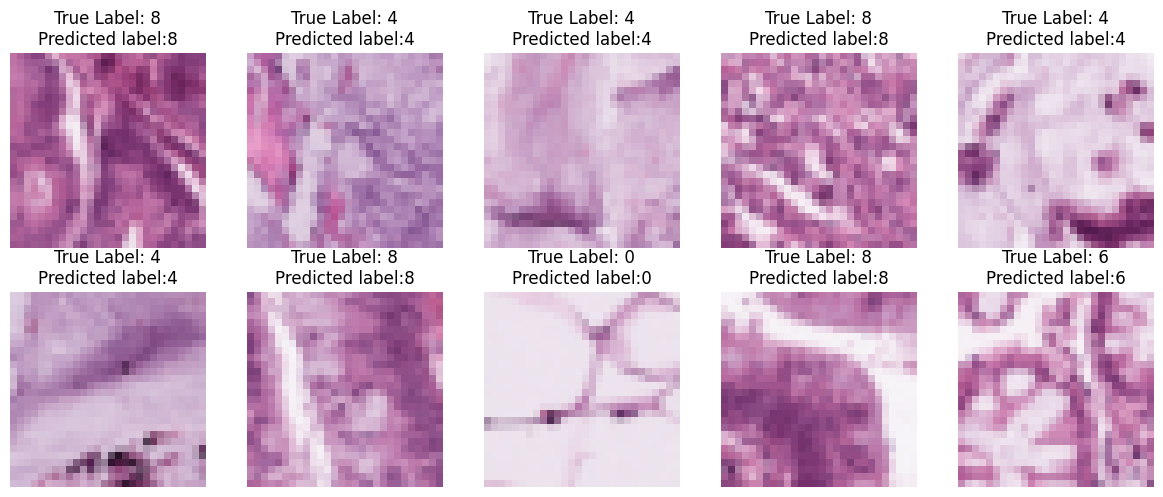

In [21]:
# Correctly classified
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Flatten axes for easy iteration
axes = axes.flatten()

selected_indices = correct_images[:10]

# Iterate through the selected indices
for i, idx in enumerate(selected_indices):
    image, label = test_loader.dataset[idx]  # Extract image and label

    # If image is RGB, swap dimensions from (C, H, W) to (H, W, C)
    mean=torch.tensor([.5])
    std=torch.tensor([.5])
    unnormalize = transforms.Normalize((-mean / std).tolist(), (1.0 / std).tolist())
    img = np.clip(unnormalize(image).numpy(),0,1)
    img = img.transpose(1, 2, 0)  # Convert from PyTorch format to Matplotlib format

    axes[i].imshow(img)  # Adjust cmap if necessary
    axes[i].set_title(f"True Label: {label[0]}\nPredicted label:{pred[idx]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

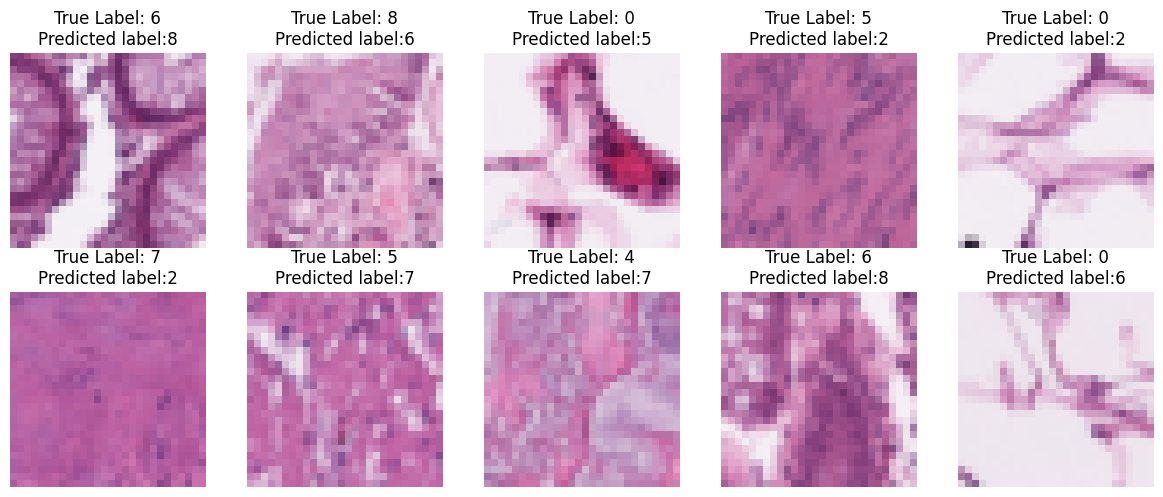

In [22]:
# Wrongly classified
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Flatten axes for easy iteration
axes = axes.flatten()

selected_indices = wrong_images[:10]

# Iterate through the selected indices
for i, idx in enumerate(selected_indices):
    image, label = test_loader.dataset[idx]  # Extract image and label

    # If image is RGB, swap dimensions from (C, H, W) to (H, W, C)
    mean=torch.tensor([.5])
    std=torch.tensor([.5])
    unnormalize = transforms.Normalize((-mean / std).tolist(), (1.0 / std).tolist())
    img = np.clip(unnormalize(image).numpy(),0,1)
    img = img.transpose(1, 2, 0)  # Convert from PyTorch format to Matplotlib format

    axes[i].imshow(img)  # Adjust cmap if necessary
    axes[i].set_title(f"True Label: {label[0]}\nPredicted label:{pred[idx]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

**Question**: Can you see some patterns that could explain why the algorithm has wrongly classified these images ? At the lowest resolution (28x28) is very difficult (I would say impossible). Choose a higher resolution and train the same code.

**Answer Q3 — Patterns in misclassified images**

At 28×28, it is nearly impossible to visually distinguish certain tissue types (PathMNIST) because the images are very low resolution. However, some common patterns in misclassifications:

* **Similar textures**: Classes like "smooth muscle" vs. "debris" or "stroma" can look almost identical at low resolution — the network simply doesn't have enough spatial information.
* **Color overlap**: Several PathMNIST classes share a similar H&E staining palette (pink/purple), so without fine-grained texture the model confuses them.
* **Ambiguous samples**: Some images are genuinely ambiguous even for human experts at this resolution.

At higher resolution (64×64 or 128×128) the textures become more distinguishable, and we can begin to see *why* the model is wrong (e.g., a debris sample with smooth-looking regions being classified as smooth muscle). This motivates the use of explainability methods.

**Question**: You probably found an error. Please change the `Net` code so that it can work with any input size. If you want to speed up computations, you can also change the number of channels. You can also change the optimization process if you wish.

**Answer Q4 — Fixing `Net` for any input size**

The original `Net` hard-codes `nn.Linear(64 * 4 * 4, 128)` which only works for 28×28 inputs. When the spatial size changes, the flattened dimension changes and we get a size mismatch. The fix is to replace the hard-coded linear layer with `nn.AdaptiveAvgPool2d(1)` which reduces any spatial size to 1×1, making the network resolution-agnostic. See the improved `FlexNet` below.

In [23]:
# Flexible CNN that works with any input size (28, 64, 128, 256...)
class FlexNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(FlexNet, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # Adaptive pooling makes the model resolution-agnostic
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

**Question**: Now that you have a working code. Implement and use at **two**  explainability methods seen during the lecture of today (e.g., Attribution, CAM, LIME) on at least **two** different networks and **two** MedMNIST datasets (e.g., PathMNISt and DermaMNIST). You can use the image size you want (the bigger, the easier to interpret but the more computational capability you will need, please choose according to your computational capability).
As network, you can use the modified `Net`and either a pre-trained Pytorch one (such as ResNet) or another custom one of your choice.

In [29]:
# --- Configuration for the explainability experiments ---
SIZE_IMAGES_XAI = 64  # 64x64 for interpretability vs speed trade-off
BATCH_SIZE_XAI = 512
NUM_EPOCHS_XAI = 10
LR_XAI = 0.001
DATASETS = ["pathmnist", "dermamnist"]

## Explainability Implementation

We implement **two** explainability methods on **two** networks x **two** datasets:

| Method | Description |
|---|---|
| **Integrated Gradients** (Attribution) | Accumulates gradients along a straight-line path from a baseline (black image) to the input. Uses Captum library. |
| **Grad-CAM** (CAM) | Uses gradients flowing into the last convolutional layer to produce a coarse localization map highlighting important regions. |

| Network | Description |
|---|---|
| **FlexNet** | Our custom CNN (32-64-128 channels, adaptive pooling) |
| **ResNet-18** | Pre-trained ImageNet model, fine-tuned |

| Dataset | Task |
|---|---|
| **PathMNIST** | Multi-class (9 tissue types) |
| **DermaMNIST** | Multi-class (7 lesion types) |

In [25]:
from captum.attr import IntegratedGradients, NoiseTunnel
import torch.nn.functional as F

# ----- Helper: build a ResNet-18 adapted to MedMNIST -----
def build_resnet18(in_channels, num_classes):
    """ResNet-18 fine-tuned for MedMNIST (handles 1 or 3 input channels)."""
    model = resnet18(weights="IMAGENET1K_V1")
    # Adapt first conv if grayscale
    if in_channels == 1:
        model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    # Replace classifier head
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# ----- Helper: unnormalize for display -----
def unnormalize(img_tensor, n_channels):
    """Undo Normalize(mean=0.5, std=0.5)"""
    mean = torch.tensor([0.5] * n_channels).view(n_channels, 1, 1)
    std = torch.tensor([0.5] * n_channels).view(n_channels, 1, 1)
    return torch.clamp(img_tensor.cpu() * std + mean, 0, 1)

print("Helpers ready.")

Helpers ready.


/root/miniconda3/envs/tp8/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 1: Load both datasets and train all four models

In [26]:
# Load both datasets
data = {}
for ds_name in DATASETS:
    train_ds, val_ds, test_ds, train_dl, val_dl, test_dl, in_ch, n_cls, tsk = \
        load_medmnist(ds_name, BATCH_SIZE_XAI, SIZE_IMAGES_XAI)
    data[ds_name] = {
        "train_loader": train_dl, "val_loader": val_dl, "test_loader": test_dl,
        "train_dataset": train_ds, "test_dataset": test_ds,
        "in_channels": in_ch, "num_classes": n_cls, "task": tsk,
    }
    print(f"\n{ds_name}: task={tsk}, classes={n_cls}, channels={in_ch}")
    print(f"  Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

100%|██████████| 1.07G/1.07G [00:09<00:00, 108MB/s] 



pathmnist: task=multi-class, classes=9, channels=3
  Train: 89996, Val: 10004, Test: 7180


100%|██████████| 100M/100M [00:01<00:00, 82.5MB/s] 



dermamnist: task=multi-class, classes=7, channels=3
  Train: 7007, Val: 1003, Test: 2005


In [30]:
# Train all 4 models: FlexNet and ResNet-18 on PathMNIST and DermaMNIST
models = {}
os.makedirs("models/", exist_ok=True)

for ds_name in DATASETS:
    d = data[ds_name]
    for net_name in ["flexnet", "resnet18"]:
        key = f"{net_name}_{ds_name}"
        ckpt_path = f"models/{key}_{SIZE_IMAGES_XAI}_{NUM_EPOCHS_XAI}.pth.tar"

        # Build model
        if net_name == "flexnet":
            m = FlexNet(d["in_channels"], d["num_classes"])
        else:
            m = build_resnet18(d["in_channels"], d["num_classes"])

        # Check if checkpoint exists
        if os.path.exists(ckpt_path):
            print(f"\n[LOAD] {key} from {ckpt_path}")
            m.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True)["state_dict"])
            m.to(device)
        else:
            print(f"\n[TRAIN] {key} for {NUM_EPOCHS_XAI} epochs on {SIZE_IMAGES_XAI}x{SIZE_IMAGES_XAI} images")
            m = train_model(m, d["train_loader"], d["val_loader"], d["task"], NUM_EPOCHS_XAI, LR_XAI)
            torch.save({"epoch": NUM_EPOCHS_XAI, "state_dict": m.state_dict()}, ckpt_path)
            print(f"  -> Saved to {ckpt_path}")

        models[key] = m

print("\nAll models ready:", list(models.keys()))


[TRAIN] flexnet_pathmnist for 10 epochs on 64x64 images


  0%|          | 0/176 [00:00<?, ?it/s]

100%|██████████| 176/176 [00:22<00:00,  7.88it/s]


Epoch 1/10, Loss: 1.7122, Accuracy: 47.79%
Epoch 1/10, Val Loss: 3.1863, Val Accuracy: 58.81%


100%|██████████| 176/176 [00:22<00:00,  7.94it/s]


...

Epoch 8/10, Loss: 0.4746, Accuracy: 83.56%
Epoch 8/10, Val Loss: 0.1804, Val Accuracy: 75.17%


100%|██████████| 14/14 [00:01<00:00, 10.00it/s]


Epoch 9/10, Loss: 0.4336, Accuracy: 85.37%
Epoch 9/10, Val Loss: 0.1785, Val Accuracy: 75.57%


100%|██████████| 14/14 [00:01<00:00, 10.11it/s]


Epoch 10/10, Loss: 0.3942, Accuracy: 87.28%
Epoch 10/10, Val Loss: 0.1791, Val Accuracy: 74.78%
  -> Saved to models/resnet18_dermamnist_64_10.pth.tar

All models ready: ['flexnet_pathmnist', 'resnet18_pathmnist', 'flexnet_dermamnist', 'resnet18_dermamnist']


In [31]:
# Evaluate all 4 models
print("=" * 60)
results = {}
for ds_name in DATASETS:
    d = data[ds_name]
    for net_name in ["flexnet", "resnet18"]:
        key = f"{net_name}_{ds_name}"
        print(f"\n--- {key} ---")
        y_t, p = evaluate(models[key], d["test_loader"], d["task"])
        correct = np.where(y_t.flatten() == p.flatten())[0]
        wrong = np.where(y_t.flatten() != p.flatten())[0]
        results[key] = {"y_true": y_t, "pred": p, "correct": correct, "wrong": wrong}
print("\nAll evaluations done.")


--- flexnet_pathmnist ---
Test Accuracy: 75.63%

--- resnet18_pathmnist ---
Test Accuracy: 93.25%

--- flexnet_dermamnist ---
Test Accuracy: 66.88%

--- resnet18_dermamnist ---
Test Accuracy: 74.31%

All evaluations done.


### Step 2: Integrated Gradients (Attribution Method)

**Integrated Gradients** (Sundararajan et al., 2017) attributes the prediction to each input feature by integrating the gradients of the output w.r.t. the input along a straight-line path from a baseline (zero image) to the actual input:

$$\text{IG}_i(x) = (x_i - x_i') \int_{\alpha=0}^{1} \frac{\partial F(x' + \alpha(x - x'))}{\partial x_i} d\alpha$$

We use the **Captum** library for the implementation.

In [ ]:
def compute_integrated_gradients(model, image_tensor, target_class, n_steps=50):
    """Compute Integrated Gradients attribution for a single image."""
    model.eval()
    ig = IntegratedGradients(model)
    image_tensor = image_tensor.unsqueeze(0).to(device).requires_grad_(True)
    attributions = ig.attribute(image_tensor, target=int(target_class), n_steps=n_steps)
    return attributions.squeeze(0).cpu().detach()


def visualize_integrated_gradients(model, dataset, indices, in_channels, ds_name, net_name, pred_labels):
    """Visualize Integrated Gradients for a set of images."""
    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = axes[None, :]

    info = INFO[ds_name]
    label_names = info["label"]

    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        true_label = int(label[0])
        predicted = int(pred_labels[idx])

        # Original image
        img_display = unnormalize(image, in_channels).numpy().transpose(1, 2, 0)
        if in_channels == 1:
            img_display = img_display.squeeze(-1)

        axes[i, 0].imshow(img_display, cmap="gray" if in_channels == 1 else None)
        true_name = label_names.get(str(true_label), str(true_label))
        pred_name = label_names.get(str(predicted), str(predicted))
        axes[i, 0].set_title(f"True: {true_name}\nPred: {pred_name}", fontsize=9)
        axes[i, 0].axis("off")

        # Compute IG for predicted class
        attr = compute_integrated_gradients(model, image, predicted)
        attr_np = attr.numpy().transpose(1, 2, 0)

        # Sum across channels for visualization
        attr_sum = np.mean(attr_np, axis=2)

        # Attribution heatmap
        vmax = max(abs(attr_sum.min()), abs(attr_sum.max()))
        axes[i, 1].imshow(attr_sum, cmap="seismic", vmin=-vmax, vmax=vmax)
        axes[i, 1].set_title("Integrated Gradients", fontsize=9)
        axes[i, 1].axis("off")

        # Overlay
        axes[i, 2].imshow(img_display, cmap="gray" if in_channels == 1 else None)
        axes[i, 2].imshow(attr_sum, cmap="seismic", alpha=0.5, vmin=-vmax, vmax=vmax)
        axes[i, 2].set_title("Overlay", fontsize=9)
        axes[i, 2].axis("off")

    fig.suptitle(f"Integrated Gradients — {net_name} on {ds_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"ig_{net_name}_{ds_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Integrated Gradients functions defined.")

### Step 3: Grad-CAM (Class Activation Mapping)

**Grad-CAM** (Selvaraju et al., 2017) computes the gradient of the class score w.r.t. the feature maps of the last convolutional layer, global-average-pools these gradients to get importance weights, and produces a weighted sum:

$$L_{\text{Grad-CAM}}^c = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right), \quad \alpha_k^c = \frac{1}{Z}\sum_i\sum_j \frac{\partial y^c}{\partial A^k_{ij}}$$

We implement this from scratch using PyTorch hooks.

In [ ]:
class GradCAM:
    """Grad-CAM implementation using PyTorch hooks."""

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        target_layer.register_forward_hook(self._forward_hook)
        target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, image_tensor, target_class=None):
        self.model.eval()
        image_tensor = image_tensor.unsqueeze(0).to(device).requires_grad_(True)

        # Forward pass
        output = self.model(image_tensor)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        # Backward pass for the target class
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1.0
        output.backward(gradient=one_hot, retain_graph=True)

        # Compute Grad-CAM
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # Global average pooling
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)  # ReLU
        cam = cam.squeeze().cpu().numpy()

        # Normalize to [0, 1]
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam


def get_target_layer(model, net_name):
    """Get the last convolutional layer for Grad-CAM."""
    if net_name == "flexnet":
        # Last conv block in features: features[-1] is ReLU, features[-2] is BN, features[-3] is Conv
        return model.features[-1]  # Last ReLU after last conv block
    elif net_name == "resnet18":
        return model.layer4[-1]  # Last BasicBlock of layer4
    else:
        raise ValueError(f"Unknown network: {net_name}")


def visualize_gradcam(model, dataset, indices, in_channels, ds_name, net_name, pred_labels):
    """Visualize Grad-CAM for a set of images."""
    target_layer = get_target_layer(model, net_name)
    gradcam = GradCAM(model, target_layer)

    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = axes[None, :]

    info = INFO[ds_name]
    label_names = info["label"]

    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        true_label = int(label[0])
        predicted = int(pred_labels[idx])

        # Original image
        img_display = unnormalize(image, in_channels).numpy().transpose(1, 2, 0)
        if in_channels == 1:
            img_display = img_display.squeeze(-1)

        axes[i, 0].imshow(img_display, cmap="gray" if in_channels == 1 else None)
        true_name = label_names.get(str(true_label), str(true_label))
        pred_name = label_names.get(str(predicted), str(predicted))
        axes[i, 0].set_title(f"True: {true_name}\nPred: {pred_name}", fontsize=9)
        axes[i, 0].axis("off")

        # Compute Grad-CAM for predicted class
        cam = gradcam(image, target_class=predicted)

        # Resize CAM to image size
        cam_resized = np.array(Image.fromarray(cam).resize(
            (img_display.shape[1], img_display.shape[0]), Image.BILINEAR))

        # CAM heatmap
        axes[i, 1].imshow(cam_resized, cmap="jet")
        axes[i, 1].set_title("Grad-CAM", fontsize=9)
        axes[i, 1].axis("off")

        # Overlay
        axes[i, 2].imshow(img_display, cmap="gray" if in_channels == 1 else None)
        axes[i, 2].imshow(cam_resized, cmap="jet", alpha=0.4)
        axes[i, 2].set_title("Overlay", fontsize=9)
        axes[i, 2].axis("off")

    fig.suptitle(f"Grad-CAM — {net_name} on {ds_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"gradcam_{net_name}_{ds_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Grad-CAM functions defined.")

### Step 4: Apply both methods on all 4 model/dataset combinations

For each combination, we select:
- 3 correctly classified images
- 2 misclassified images

and visualize both Integrated Gradients and Grad-CAM.

In [ ]:
# Apply Integrated Gradients and Grad-CAM on all 4 combinations
N_CORRECT = 3
N_WRONG = 2

for ds_name in DATASETS:
    d = data[ds_name]
    for net_name in ["flexnet", "resnet18"]:
        key = f"{net_name}_{ds_name}"
        model = models[key]
        res = results[key]

        # Select indices (mix of correct and wrong)
        np.random.seed(42)
        correct_sel = np.random.choice(res["correct"], min(N_CORRECT, len(res["correct"])), replace=False)
        wrong_sel = np.random.choice(res["wrong"], min(N_WRONG, len(res["wrong"])), replace=False)
        selected = list(correct_sel) + list(wrong_sel)

        print(f"\n{'='*60}")
        print(f"  {key.upper()}: {len(correct_sel)} correct + {len(wrong_sel)} wrong samples")
        print(f"{'='*60}")

        # --- Integrated Gradients ---
        print(f"\n--- Integrated Gradients for {key} ---")
        visualize_integrated_gradients(
            model, d["test_dataset"], selected, d["in_channels"],
            ds_name, net_name, res["pred"]
        )

        # --- Grad-CAM ---
        print(f"\n--- Grad-CAM for {key} ---")
        visualize_gradcam(
            model, d["test_dataset"], selected, d["in_channels"],
            ds_name, net_name, res["pred"]
        )

### Step 5: Comparative side-by-side visualization

Below we show, for one sample per dataset, both methods side by side for both networks, enabling direct comparison.

In [ ]:
# Comparative visualization: same image, both methods, both networks
for ds_name in DATASETS:
    d = data[ds_name]
    in_ch = d["in_channels"]
    info = INFO[ds_name]
    label_names = info["label"]

    # Pick one correctly classified sample (by both models)
    res_flex = results[f"flexnet_{ds_name}"]
    res_res = results[f"resnet18_{ds_name}"]
    common_correct = np.intersect1d(res_flex["correct"], res_res["correct"])
    np.random.seed(123)
    idx = np.random.choice(common_correct, 1)[0]

    image, label = d["test_dataset"][idx]
    true_label = int(label[0])
    true_name = label_names.get(str(true_label), str(true_label))

    fig, axes = plt.subplots(2, 5, figsize=(22, 9))

    for row, net_name in enumerate(["flexnet", "resnet18"]):
        key = f"{net_name}_{ds_name}"
        model = models[key]
        predicted = int(results[key]["pred"][idx])
        pred_name = label_names.get(str(predicted), str(predicted))

        # Original
        img_display = unnormalize(image, in_ch).numpy().transpose(1, 2, 0)
        if in_ch == 1:
            img_display = img_display.squeeze(-1)

        axes[row, 0].imshow(img_display, cmap="gray" if in_ch == 1 else None)
        axes[row, 0].set_title(f"Original\nTrue: {true_name}", fontsize=9)
        axes[row, 0].set_ylabel(net_name.upper(), fontsize=12, fontweight="bold")
        axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])

        # IG
        attr = compute_integrated_gradients(model, image, predicted)
        attr_sum = np.mean(attr.numpy().transpose(1, 2, 0), axis=2)
        vmax = max(abs(attr_sum.min()), abs(attr_sum.max())) + 1e-8

        axes[row, 1].imshow(attr_sum, cmap="seismic", vmin=-vmax, vmax=vmax)
        axes[row, 1].set_title(f"Integrated Grad.\nPred: {pred_name}", fontsize=9)
        axes[row, 1].axis("off")

        # IG overlay
        axes[row, 2].imshow(img_display, cmap="gray" if in_ch == 1 else None)
        axes[row, 2].imshow(attr_sum, cmap="seismic", alpha=0.5, vmin=-vmax, vmax=vmax)
        axes[row, 2].set_title("IG Overlay", fontsize=9)
        axes[row, 2].axis("off")

        # Grad-CAM
        target_layer = get_target_layer(model, net_name)
        gradcam = GradCAM(model, target_layer)
        cam = gradcam(image, target_class=predicted)
        cam_resized = np.array(Image.fromarray(cam).resize(
            (img_display.shape[1], img_display.shape[0]), Image.BILINEAR))

        axes[row, 3].imshow(cam_resized, cmap="jet")
        axes[row, 3].set_title("Grad-CAM", fontsize=9)
        axes[row, 3].axis("off")

        # Grad-CAM overlay
        axes[row, 4].imshow(img_display, cmap="gray" if in_ch == 1 else None)
        axes[row, 4].imshow(cam_resized, cmap="jet", alpha=0.4)
        axes[row, 4].set_title("CAM Overlay", fontsize=9)
        axes[row, 4].axis("off")

    fig.suptitle(f"Comparison — {ds_name} (sample #{idx})", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"comparison_{ds_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

### Analysis and Conclusions

**Integrated Gradients vs Grad-CAM:**

- **Integrated Gradients** produces pixel-level attributions: it shows exactly *which pixels* positively or negatively contribute to the prediction. The red/blue seismic maps are fine-grained and can highlight textures and edges. However, they can be noisy and harder to interpret at a glance.
- **Grad-CAM** produces coarser, region-level explanations based on the last convolutional layer. It highlights *where* the network is looking, not precisely *which pixels* matter. This is more intuitive to interpret but loses spatial detail.

**FlexNet vs ResNet-18:**

- **ResNet-18** generally achieves higher accuracy thanks to pre-trained ImageNet features and skip connections. Its Grad-CAM maps tend to be more focused because the deeper architecture has richer feature representations.
- **FlexNet** is a simpler model with fewer parameters. Its attributions can be more diffuse, reflecting its simpler learned features.

**PathMNIST vs DermaMNIST:**

- **PathMNIST** (histopathology): the models tend to look at tissue texture patterns. Grad-CAM highlights cellular structures and tissue organization.
- **DermaMNIST** (dermatoscopy): the models focus on lesion boundaries, color patterns, and structural features typical of dermatological diagnosis.

**Key takeaway:** Using multiple explainability methods gives complementary insights — attribution methods reveal pixel importance while CAM methods reveal spatial attention. Comparing across architectures helps assess whether the explanations are model-specific or capture genuine data patterns.